In [1]:
using Distributions
using MCMCChains
using MLDataUtils: rescale!, shuffleobs, stratifiedobs
using Plots
using Random
using RDatasets
using StatsFuns: logistic
using StatsPlots
using Turing

Random.seed!(414)
Turing.turnprogress(false)

┌ Info: [Turing]: global PROGRESS is set as false
└ @ Turing /Users/dsp/.julia/packages/Turing/LONxt/src/Turing.jl:25


false

In [2]:
data = RDatasets.dataset("ISLR", "Default")
first(data, 6)

,Default,Student,Balance,Income
,Categorical…,Categorical…,Float64,Float64
1,No,No,729.526,44361.6
2,No,Yes,817.18,12106.1
3,No,No,1073.55,31767.1
4,No,No,529.251,35704.5
5,No,No,785.656,38463.5
6,No,Yes,919.589,7491.56


In [3]:
# Y/N = 1/0
data[!, :Default] = 1. .* (data[!, :Default] .== "Yes")
data[!, :Student] = 1. .* (data[!, :Student] .== "Yes")
first(data, 6)

,Default,Student,Balance,Income
,Float64,Float64,Float64,Float64
1,0.0,0.0,729.526,44361.6
2,0.0,1.0,817.18,12106.1
3,0.0,0.0,1073.55,31767.1
4,0.0,0.0,529.251,35704.5
5,0.0,0.0,785.656,38463.5
6,0.0,1.0,919.589,7491.56


In [4]:
function splitdata(df, target; at=0.7)
    shuffled = shuffleobs(df)
    train, test = stratifiedobs(row -> row[target], shuffled, p=at)
end

splitdata (generic function with 1 method)

In [5]:
features = [:Student, :Balance, :Income]
numerics = [:Balance, :Income]
target = :Default
train, test = splitdata(data, target, at=0.05);

In [6]:
for feature in numerics
    mu, sig = rescale!(train[!, feature], obsdim=1)
    rescale!(test[!, feature], mu, sig, obsdim=1)
end

In [7]:
Xtrain = Matrix(train[:, features])
Xtest = Matrix(test[:, features])
ytrain = train[:, target]
ytest = test[:, target];

In [14]:
@model logistic_regression(x, y, n, sig) = begin
    intercept ~ Normal(0, sig)
    student ~ Normal(0, sig)
    balance ~ Normal(0, sig)
    income ~ Normal(0, sig)
    for i = 1:n
        v = logistic(
            intercept + student*x[i, 1] + balance*x[i, 2] + income*x[i, 3]
        )
        y[i] ~ Bernoulli(v)
    end
end

(::DynamicPPL.ModelGen{(:x, :y, :n, :sig),var"###logistic_regression#455",NamedTuple{(),Tuple{}}}) (generic function with 1 method)

In [15]:
n, _ = size(train)
chain = mapreduce(c -> 
    sample(logistic_regression(Xtrain, ytrain, n, 1), 
           HMC(0.05, 10), 1500),
    chainscat,
    1:3)
describe(chain)

2-element Array{ChainDataFrame,1}

Summary Statistics
. Omitted printing of 1 columns
│ Row │ parameters │ mean       │ std      │ naive_se   │ mcse       │ ess     │
│     │ Symbol     │ Float64    │ Float64  │ Float64    │ Float64    │ Any     │
├─────┼────────────┼────────────┼──────────┼────────────┼────────────┼─────────┤
│ 1   │ balance    │ 1.93434    │ 0.325129 │ 0.00484673 │ 0.0090387  │ 197.66  │
│ 2   │ income     │ -0.0472966 │ 0.34763  │ 0.00518216 │ 0.00933672 │ 639.094 │
│ 3   │ intercept  │ -4.52997   │ 0.499422 │ 0.00744494 │ 0.018353   │ 111.644 │
│ 4   │ student    │ -0.286751  │ 0.607864 │ 0.00906151 │ 0.0221028  │ 582.293 │

Quantiles

│ Row │ parameters │ 2.5%      │ 25.0%     │ 50.0%      │ 75.0%    │ 97.5%    │
│     │ Symbol     │ Float64   │ Float64   │ Float64    │ Float64  │ Float64  │
├─────┼────────────┼───────────┼───────────┼────────────┼──────────┼──────────┤
│ 1   │ balance    │ 1.35504   │ 1.71867   │ 1.92307    │ 2.12184  │ 2.55805  │
│ 2   │ income 

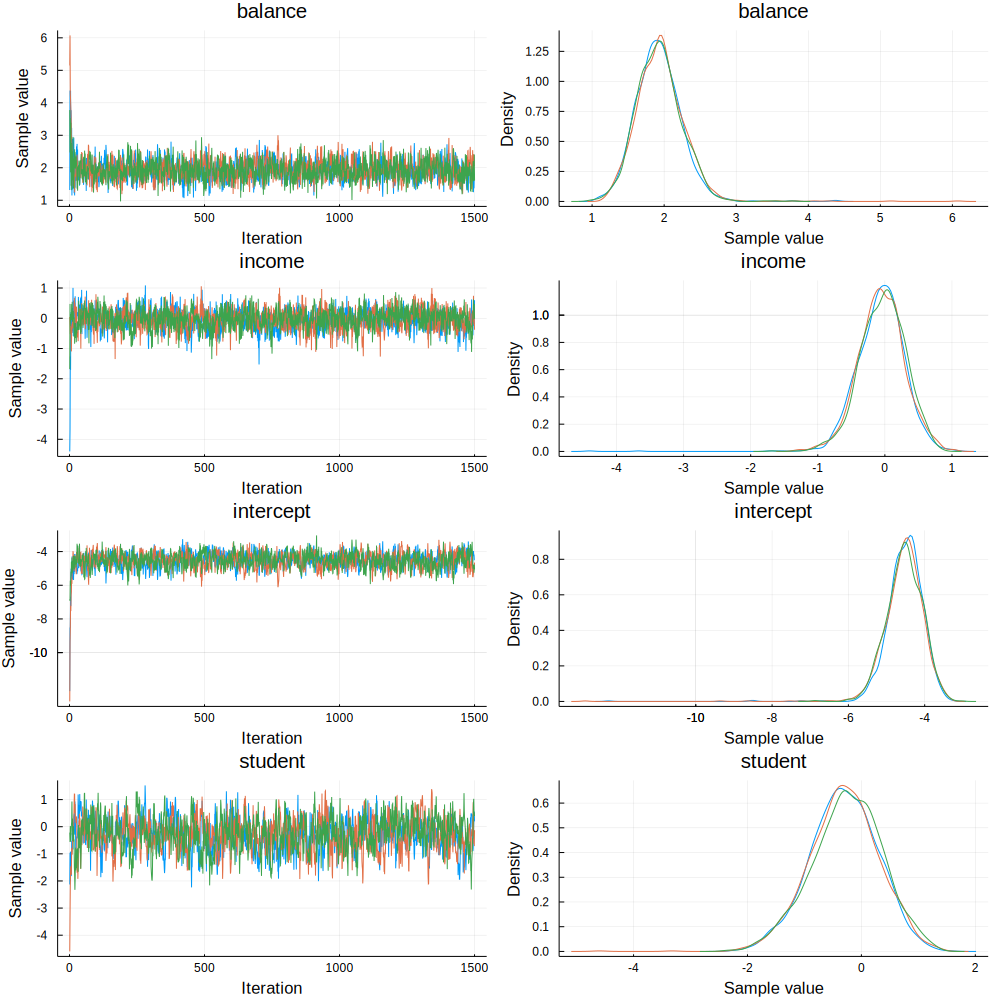

In [16]:
plot(chain)

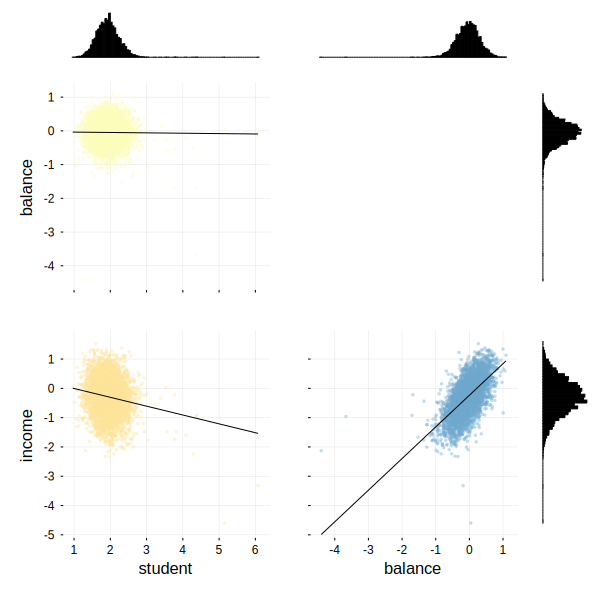

In [17]:
labels = [:student, :balance, :income]
corner(chain, labels)